# 16 Classical feature importance

Ranks standardized coefficients from the selected L2-regularized logistic-regression baseline. Expert hotspot annotations remain excluded from predictors.

BASE_DIR: /content
PROJECT_ROOT: /content/project_thermography_equine
OUTPUT_ROOT: /content/project_thermography_equine/outputs
Loaded /content/project_thermography_equine/outputs/config/classical_features.csv shape=(347, 46)
Loaded model: /content/project_thermography_equine/outputs/config/selected_classical_model.joblib


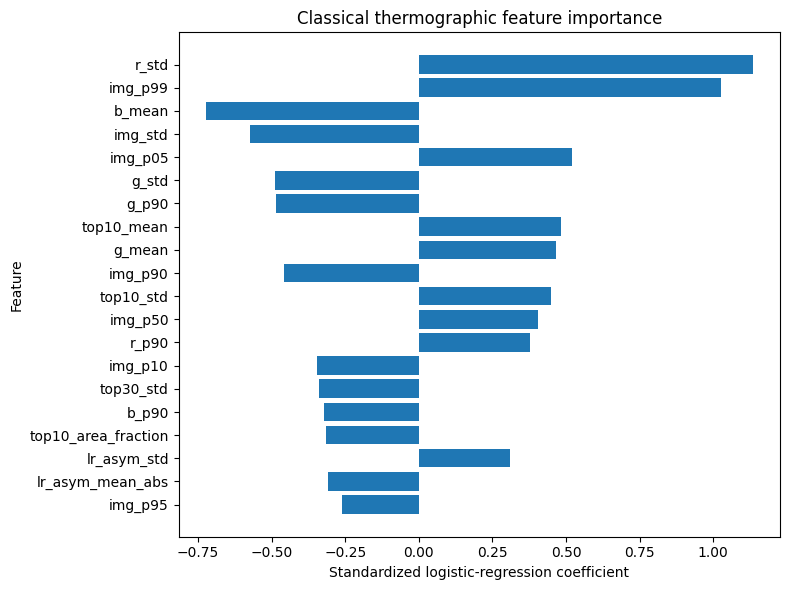

 rank    feature  logistic_coefficient_standardized  absolute_coefficient                        direction  healthy_mean  pathological_mean  healthy_median  pathological_median  mean_difference_pathological_minus_healthy
    1      r_std                           1.134450              1.134450 higher_values_favor_pathological     58.651235          73.212192       58.775745            77.234024                                   14.560957
    2    img_p99                           1.027832              1.027832 higher_values_favor_pathological    202.985409         209.516667      211.000000           212.000000                                    6.531258
    3     b_mean                          -0.723062              0.723062      higher_values_favor_healthy     31.394034          34.858633       16.808414            12.945512                                    3.464599
    4    img_std                          -0.572232              0.572232      higher_values_favor_healthy     53.75

In [2]:

from pathlib import Path
import os, json, glob, shutil, warnings, math, random
from datetime import datetime, timezone
import numpy as np
import pandas as pd

SEED = int(os.environ.get("THERMO_SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)

_candidate_bases = [Path(os.environ.get("THERMO_BASE_DIR", "")) if os.environ.get("THERMO_BASE_DIR") else None,
                    Path("/content"), Path("/mnt/data"), Path.cwd(), Path("/tmp")]
_candidate_bases = [p for p in _candidate_bases if p is not None]

def _base_is_usable(p):
    try:
        return p.exists() and os.access(p, os.W_OK)
    except Exception:
        return False

BASE_DIR = next((p for p in _candidate_bases if _base_is_usable(p)), Path("/tmp"))
PROJECT_NAME = os.environ.get("THERMO_PROJECT_NAME", "project_thermography_equine")
PROJECT_ROOT = BASE_DIR / PROJECT_NAME
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
CONFIG_DIR = OUTPUT_ROOT / "config"
REPORTS_DIR = OUTPUT_ROOT / "reports"
TABLES_DIR = OUTPUT_ROOT / "tables"
FIGURES_DIR = OUTPUT_ROOT / "figures"
MODELS_DIR = OUTPUT_ROOT / "models"
GRADCAM_DIR = OUTPUT_ROOT / "gradcam"
XAI_DIR = OUTPUT_ROOT / "xai_integrated_gradients"
for d in [PROJECT_ROOT, DATA_ROOT, OUTPUT_ROOT, CONFIG_DIR, REPORTS_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR, GRADCAM_DIR, XAI_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEARCH_ROOTS = [PROJECT_ROOT, OUTPUT_ROOT, CONFIG_DIR, REPORTS_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR, GRADCAM_DIR, BASE_DIR, Path('/content'), Path('/mnt/data'), Path.cwd()]

def find_first(patterns, roots=SEARCH_ROOTS, required=False):
    hits=[]
    for root in roots:
        root=Path(root)
        if not root.exists():
            continue
        for pat in patterns:
            hits.extend([p for p in root.rglob(pat) if p.is_file() and '.ipynb_checkpoints' not in p.parts])
    hits=sorted(set(hits), key=lambda p: p.stat().st_mtime, reverse=True)
    if required and not hits:
        raise FileNotFoundError(f"Could not find any of: {patterns}")
    return hits[0] if hits else None

def read_csv_found(patterns, required_cols=None, required=True):
    path=find_first(patterns, required=required)
    if path is None:
        return None, None
    df=pd.read_csv(path)
    if required_cols:
        missing=[c for c in required_cols if c not in df.columns]
        if missing:
            raise KeyError(f"{path} missing required columns: {missing}")
    print(f"Loaded {path} shape={df.shape}")
    return df, path

def save_text(path, text):
    path=Path(path); path.parent.mkdir(parents=True, exist_ok=True); path.write_text(text, encoding='utf-8')

print('BASE_DIR:', BASE_DIR)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('OUTPUT_ROOT:', OUTPUT_ROOT)

import matplotlib.pyplot as plt
import joblib

features, features_path = read_csv_found(["classical_features.csv"], required_cols=["split", "label_binary"], required=True)
meta_path = find_first(["classical_feature_metadata.json"], required=True)
meta = json.loads(Path(meta_path).read_text(encoding='utf-8'))
feature_columns = meta.get("feature_columns")
if not feature_columns:
    non_feature_cols = {"horse_id", "image_name", "split", "label_clinical", "label_binary", "relative_image_path", "feature_image_path",
                        "clean_image_path", "healthy_with_expert_hotspot", "healthy_with_expert_annotation_flag",
                        "annotation_label_conflict", "annotation_clinical_note", "included_in_final_analysis"}
    feature_columns = [c for c in features.columns if c not in non_feature_cols and pd.api.types.is_numeric_dtype(features[c])]
feature_columns = [c for c in feature_columns if c in features.columns]

model_path = find_first(["selected_classical_model.joblib", "*classical*model*.joblib"], required=True)
model = joblib.load(model_path)
print("Loaded model:", model_path)

# Extract coefficients from a scikit-learn Pipeline with imputer/scaler/logistic regression.
if hasattr(model, 'named_steps'):
    final_est = list(model.named_steps.values())[-1]
else:
    final_est = model
if not hasattr(final_est, 'coef_'):
    raise TypeError("Selected classical model does not expose coef_. Feature importance script expects logistic regression.")
coefs = np.asarray(final_est.coef_).ravel()
if len(coefs) != len(feature_columns):
    raise ValueError(f"Number of coefficients ({len(coefs)}) does not match number of features ({len(feature_columns)}).")

# Descriptive statistics by clinical label for biological interpretation.
summary = features.groupby('label_binary')[feature_columns].agg(['mean','std','median']).T.reset_index()
summary.columns = ['feature','statistic'] + [f'label_{c}' for c in summary.columns[2:]]

importance = pd.DataFrame({
    "feature": feature_columns,
    "logistic_coefficient_standardized": coefs,
    "absolute_coefficient": np.abs(coefs),
    "direction": np.where(coefs>0, "higher_values_favor_pathological", np.where(coefs<0, "higher_values_favor_healthy", "neutral")),
}).sort_values("absolute_coefficient", ascending=False).reset_index(drop=True)
importance.insert(0, "rank", np.arange(1, len(importance)+1))

# Add class-wise means/medians when available.
desc = []
for f in feature_columns:
    h = features.loc[features['label_binary'].astype(int)==0, f]
    p = features.loc[features['label_binary'].astype(int)==1, f]
    desc.append({
        "feature": f,
        "healthy_mean": h.mean(), "pathological_mean": p.mean(),
        "healthy_median": h.median(), "pathological_median": p.median(),
        "mean_difference_pathological_minus_healthy": p.mean()-h.mean()
    })
desc = pd.DataFrame(desc)
importance = importance.merge(desc, on='feature', how='left')

for p in [CONFIG_DIR/"classical_feature_importance.csv", REPORTS_DIR/"classical_feature_importance.csv", TABLES_DIR/"table_classical_feature_importance.csv"]:
    importance.to_csv(p, index=False)
summary.to_csv(CONFIG_DIR/"classical_feature_descriptive_statistics_by_label.csv", index=False)
summary.to_csv(REPORTS_DIR/"classical_feature_descriptive_statistics_by_label.csv", index=False)

# Plot top 20 absolute coefficients.
top = importance.head(min(20, len(importance))).iloc[::-1]
plt.figure(figsize=(8, max(4, 0.3*len(top))))
plt.barh(top['feature'], top['logistic_coefficient_standardized'])
plt.xlabel("Standardized logistic-regression coefficient")
plt.ylabel("Feature")
plt.title("Classical thermographic feature importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR/"classical_feature_importance_top20.png", dpi=300)
plt.show()

diagnostics = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "analysis": "classical_feature_importance",
    "model_path": str(model_path),
    "features_path": str(features_path),
    "n_features": int(len(feature_columns)),
    "n_images": int(len(features)),
    "leakage_policy": "Expert hotspot annotations and annotation-derived variables are not used as predictors.",
}
save_text(CONFIG_DIR/"classical_feature_importance_diagnostics.json", json.dumps(diagnostics, indent=2))
save_text(REPORTS_DIR/"methods_classical_feature_importance_text.txt", "Feature importance for the selected L2-regularized logistic-regression baseline was quantified using standardized model coefficients. Predictors were image-derived thermographic biomarkers only; expert hotspot annotations were excluded from the predictor matrix. Coefficients were ranked by absolute magnitude, and coefficient direction was interpreted with respect to the pathological class.\n")
print(importance.head(15).to_string(index=False))


## Completion
Use `table_classical_feature_importance.csv` as Supplementary Table for the manuscript.